In [1]:
import tensorflow as tf
from tensorflow import keras
from keras import layers

import numpy as np
import matplotlib.pyplot as plt

In [2]:
(train_input, train_target), (test_input, test_target) = keras.datasets.fashion_mnist.load_data()

In [5]:
train_input.shape

(60000, 28, 28)

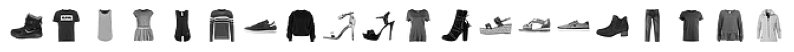

In [7]:
import matplotlib.pyplot as plt
fig, axs = plt.subplots(1, 20, figsize=(10,10))
for i  in range(20):
    axs[i].imshow(train_input[i], cmap ='gray_r')
    axs[i].axis('off')
plt.show()

In [5]:
cloth_classify = ['Boot','T-shirt', 'Top', 'Dress', 'High-heel'
                  , 'Shirt','Sandal', 'Pants']

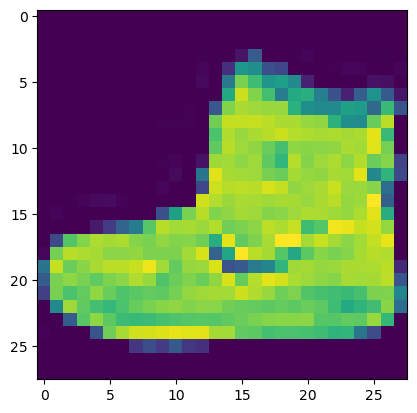

In [6]:
plt.imshow(train_input[0])

# 데이터 표준화
이미지데이터에도 해줘야하나 했는데 하면 좋다고 하네요
+ 표준화 시 이미지데이터에 혹여나 변동이 있나 다시 출력해서 체크해보는게 좋음

In [8]:
train_input = train_input / 255.0
train_target = train_target / 255.0

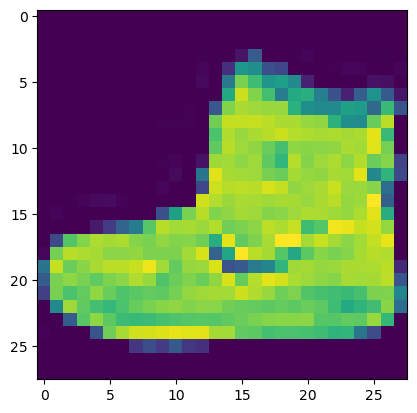

In [9]:
plt.imshow(train_input[0])

# Model 설정

In [11]:
model = keras.Sequential([
    layers.Flatten(input_shape=(28, 28)), # 2D데이터를 1D벡터로 변환 (28 x 28 = 784)
    layers.Dense(128, activation='relu'), # # 노드 128, relu 사용
    layers.Dense(10, activation='softmax') # softmax를 통해 확률 중 가장 높은거 선정
])

C:\Users\07491\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# compile : 손실함수, 옵티마이저, 평가 지표 설정
# sparse_categorical_crossentropy : 손실함수 측정 - 얘를 축소하는 방향으로 모델이 학습
# adam : 학습속도 빠르고 동적임, SGD, RMSProp 장점을 모은 방식

model.compile(loss='sparse_categorical_crossentropy'
              , optimizer='adam', metrics=['accuracy'])

# 모델 과적합시 스탑
# patience: 모델이 개선되지 않아도 10번쯤은 기다려보자~ (손실값 안떨어지면 스탑)
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10)

In [20]:
history = model.fit(train_input, train_target, epochs=10
                    , validation_split=0.2, batch_size=64, callbacks=[early_stop])

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0988 - loss: 2.7581e-08 - val_accuracy: 0.1030 - val_loss: 1.6093e-08
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1000 - loss: 3.3101e-08 - val_accuracy: 0.1030 - val_loss: 1.1364e-08
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1022 - loss: 1.7758e-08 - val_accuracy: 0.1030 - val_loss: 8.0466e-09
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0991 - loss: 9.9279e-09 - val_accuracy: 0.1030 - val_loss: 5.6624e-09
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0993 - loss: 4.1742e-09 - val_accuracy: 0.1030 - val_loss: 4.0332e-09
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0997 - loss: 4.5634e-09 - val_accuracy: 0.1030 - val_loss: 2.9802e-09
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1000 - loss: 2.7463e-09 - val_accuracy: 0.1030 - val_loss: 2.2252e-09
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/s

# 모델 평가 및 예측

In [22]:
model.evaluate(test_input,test_target)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 998us/step - accuracy: 0.1001 - loss: 22863.6543


[22790.58984375, 0.10000000149011612]

In [31]:
pred = model.predict(test_input)[0]
# sum(model.predict(test_input)[0])
# plt.bar(cloth_classify, pred)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 749us/step


IndexError: list index out of range

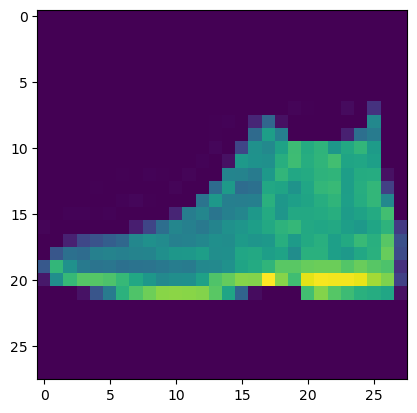

In [33]:
plt.imshow(test_input[0])
print(cloth_classify[test_target[0]])

# 못맞춘 데이터 찾기 !! 수정

In [41]:
pred = model.predict(test_input).argmax(axis=1)
test_target==pred

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 773us/step


array([False, False, False, ..., False, False, False])

In [45]:
# 몇번째 타겟이 틀렸나
np.where(test_target == pred)

(array([  19,   27,   35,   59,   71,   85,   88,   96,  113,  120,  121,
         125,  141,  142,  143,  155,  164,  170,  177,  180,  201,  206,
         223,  229,  235,  260,  263,  264,  272,  275,  280,  284,  304,
         305,  332,  341,  355,  359,  370,  374,  381,  395,  400,  403,
         410,  440,  452,  454,  458,  463,  464,  472,  488,  489,  499,
         501,  531,  544,  547,  566,  577,  589,  605,  610,  616,  625,
         636,  646,  651,  652,  656,  672,  674,  677,  681,  691,  703,
         714,  719,  720,  731,  736,  737,  751,  755,  764,  770,  858,
         859,  881,  889,  890,  894,  906,  908,  910,  916,  926,  930,
         937,  948,  951,  954,  955,  959,  965,  985, 1000, 1005, 1038,
        1049, 1052, 1060, 1069, 1111, 1124, 1139, 1158, 1169, 1203, 1205,
        1207, 1214, 1216, 1218, 1231, 1249, 1252, 1260, 1270, 1273, 1285,
        1287, 1293, 1295, 1305, 1340, 1358, 1364, 1371, 1372, 1379, 1399,
        1403, 1412, 1428, 1450, 1451, 

TypeError: Invalid shape () for image data

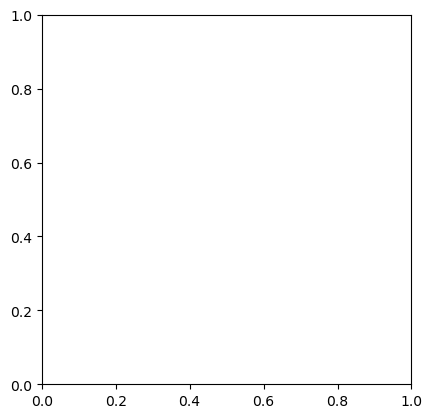

In [49]:
# 해당 타겟 체크
plt.imshow(test_target[19])

In [51]:
pred = model.predict(test_target)
plt.bar(cloth_classify, pred[19])

ValueError: Exception encountered when calling Sequential.call().

[1mCannot take the length of shape with unknown rank.[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=<unknown>, dtype=uint8)
  • training=False
  • mask=None

In [53]:
cloth_classify[test_target[19]]

'Boot'

### 고려사항
+ !! 못맞춘 데이터를 어떻게 처리해야할까 !!
+ Flatten > CNN이 이미지 처리에는 특화되어 있다네요
+ 노드 수, 활성화 함수(ReLU) 보다 좋은 성능을 위해서 추가적인 하이퍼 파라미터 튜닝
+ patience값 실험을 통해 조정
+ 간단한 데이터셋은 Sequential, 복잡한 데이터셋은 무리가 있음. 
+ 따라서 복잡한 데이터셋은 Residual Networks 또는 Transformer 등을 사용


### CNN 으로 해보기 
https://dacon.io/codeshare/4599?dtype=recent
88.3 > 88.9